# 06 — Candidate sensitivity

How sensitive is the unmixing model to the presence of individual top
candidates? We build the vote matrix once (same preprocessing as
`02_unmixing_pipeline`), then generate one **dataset variation per top-N
candidate**: in each, that single candidate's row is removed from `Y` and the
full pipeline (noise → HySime → MVSA → SUNSAL) is re-run on the reduced matrix.

Keeping the precincts and the normalization fixed across variations isolates
the effect of dropping *that one candidate* on the reconstruction of all the
others. For every candidate reconstruction heatmap we overlay a **linear
regression** (reconstructed vs. original vote fraction), and the notebook ends
with a summary of those fits across all dataset variations.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress
from src.config import load_config

sns.set_style('whitegrid')
config = load_config()

# How many top candidates to remove, one at a time (each = one dataset variation).
TOP_N = 12

In [2]:
from src.data import load_complete
from src.data.preprocessing import preprocess_from_config
from src.unmixing import est_noise, hysime, mvsa, sunsal_mod

SEED = config['unmixing'].getint('seed')
np.random.seed(SEED)

df = load_complete(config)
pre = preprocess_from_config(df, config)
Y_raw = pre.Y_raw
Y = pre.Y
L, N = Y.shape
labels = pre.candidate_labels

# Fixed number of archetypes so reconstructions are comparable across variations.
P = config['unmixing'].getint('n_archetypes') or None


def short_label(lab):
    """'GO, BONG GO (PDPLBN) [1]' -> 'GO, BONG GO [1]'."""
    name = lab.split(' (')[0]
    rank = lab.rsplit('[', 1)[-1].rstrip(']')
    return f'{name} [{rank}]'


print(f'Baseline Y: {L} candidates x {N:,} precincts')
print(f'Removing each of the top {TOP_N} candidates in turn:')
for i in range(TOP_N):
    print(f'  {i+1:>2}. {labels[i]}')

candidates: 66 -> 66 (25th pct >= 1.0)
precincts:  92,488 -> 92,487 (total votes >= 1.0)
Y: 66 candidates x 92,487 precincts (valid_ballots normalization)
Baseline Y: 66 candidates x 92,487 precincts
Removing each of the top 12 candidates in turn:
   1. GO, BONG GO (PDPLBN) [1]
   2. AQUINO, BAM (KNP) [2]
   3. DELA ROSA, BATO (PDPLBN) [3]
   4. TULFO, ERWIN (LAKAS) [4]
   5. PANGILINAN, KIKO (LP) [5]
   6. LACSON, PING (IND) [6]
   7. MARCOLETA, RODANTE (IND) [7]
   8. SOTTO, TITO (NPC) [8]
   9. CAYETANO, PIA (NP) [9]
  10. VILLAR, CAMILLE (NP) [10]
  11. LAPID, LITO (NPC) [11]
  12. MARCOS, IMEE R. (NP) [12]


## Pipeline as a reusable function

Wraps the four stages of `02_unmixing_pipeline` so we can call it on the full
matrix and on each candidate-removed matrix. The number of archetypes `P` is
held fixed (config `n_archetypes`) so the reconstructions are directly
comparable; the RNG is reseeded on every call for reproducibility.

In [3]:
def run_pipeline(Y_in, p=P, seed=SEED, verbose=False):
    np.random.seed(seed)
    w_hat, Rw_hat = est_noise(Y_in, noise_type='additive', verbose=False)
    kf, Ek, E, delta_p = hysime(Y_in, w_hat, Rw_hat, verbose=False)
    n_arch = p or kf
    endm, Sest, Up, my, sing_values = mvsa(
        Y_in, p=n_arch,
        MM_iters=config['unmixing'].getint('mvsa_mm_iters'),
        spherize='yes', verbose=0)
    abundances, res_p, res_d = sunsal_mod(
        endm, Y_in, positivity='yes', addone='yes',
        AL_iters=config['unmixing'].getint('sunsal_al_iters'),
        lambda_=0.0, tol=config['unmixing'].getfloat('sunsal_tol'), verbose='no')
    Y_rec = endm @ abundances
    rmse = float(np.sqrt(np.mean((Y_in - Y_rec) ** 2)))
    if verbose:
        print(f'kf={kf}, n_arch={n_arch}, RMSE={rmse:.6f}')
    return {'endm': endm, 'abundances': abundances, 'kf': int(kf),
            'n_arch': int(n_arch), 'rmse': rmse}


def candidate_fits(Y_in, endm, abundances, keep):
    """Per-candidate linear fit of reconstructed vs. original vote fraction.

    Returns {orig_candidate_index: dict(slope, intercept, r2, rmse)}.
    """
    Y_rec = endm @ abundances
    fits = {}
    for row, orig_i in enumerate(keep):
        lr = linregress(Y_in[row, :], Y_rec[row, :])
        rmse_i = float(np.sqrt(np.mean((Y_in[row, :] - Y_rec[row, :]) ** 2)))
        fits[orig_i] = {'slope': float(lr.slope), 'intercept': float(lr.intercept),
                        'r2': float(lr.rvalue ** 2), 'rmse': rmse_i}
    return fits

## Baseline (full dataset)

Reference fit with every candidate present.

In [4]:
base = run_pipeline(Y, verbose=True)
base_keep = list(range(L))
base['keep'] = base_keep
base['fit'] = candidate_fits(Y, base['endm'], base['abundances'], base_keep)
print(f"Baseline RMSE = {base['rmse']:.6f}, kf = {base['kf']}")

/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(


SNR estimated = -inf[dB]
... Select the projective proj.
kf=7, n_arch=6, RMSE=0.033695
Baseline RMSE = 0.033695, kf = 7


## Dataset variations — remove one top candidate at a time

For each of the top `TOP_N` candidates we delete its row from `Y`, re-run the
whole pipeline on the reduced matrix, and store the endmembers, abundances, and
per-candidate linear fits. We keep only compact results (abundances are small;
reconstructions are recomputed on demand as `endm @ abundances`).

In [5]:
results = []  # one entry per removed candidate

for k in range(TOP_N):
    keep = [j for j in range(L) if j != k]
    Y_reduced = Y[keep, :]
    res = run_pipeline(Y_reduced)
    res['removed_idx'] = k
    res['removed_label'] = labels[k]
    res['keep'] = keep
    res['fit'] = candidate_fits(Y_reduced, res['endm'], res['abundances'], keep)
    results.append(res)
    print(f"removed [{k+1:>2}] {labels[k]:<34} -> RMSE = {res['rmse']:.6f}, kf = {res['kf']}")

print('\nDone:', len(results), 'dataset variations.')

SNR estimated = -inf[dB]
... Select the projective proj.
removed [ 1] GO, BONG GO (PDPLBN) [1]           -> RMSE = 0.033063, kf = 6
SNR estimated = -inf[dB]
... Select the projective proj.
removed [ 2] AQUINO, BAM (KNP) [2]              -> RMSE = 0.032758, kf = 6
SNR estimated = -inf[dB]
... Select the projective proj.
removed [ 3] DELA ROSA, BATO (PDPLBN) [3]       -> RMSE = 0.033293, kf = 6
SNR estimated = -inf[dB]
... Select the projective proj.
removed [ 4] TULFO, ERWIN (LAKAS) [4]           -> RMSE = 0.033268, kf = 7
SNR estimated = -inf[dB]
... Select the projective proj.
removed [ 5] PANGILINAN, KIKO (LP) [5]          -> RMSE = 0.033223, kf = 6
SNR estimated = -inf[dB]
... Select the projective proj.
removed [ 6] LACSON, PING (IND) [6]             -> RMSE = 0.033332, kf = 6
SNR estimated = -inf[dB]
... Select the projective proj.
removed [ 7] MARCOLETA, RODANTE (IND) [7]       -> RMSE = 0.033252, kf = 6
SNR estimated = -inf[dB]
... Select the projective proj.
removed [ 8] SOTTO,

### Candidate reconstruction heatmaps with linear fit

For a chosen dataset variation, each panel is the 2-D density of *reconstructed*
vs. *original* vote fraction for one candidate. The dashed black line is the
ideal `y = x`; the solid red line is the **least-squares linear fit** of the
reconstruction. A slope near 1 with a small intercept and high R² means the
archetype model reproduces that candidate's precinct-level distribution well.

In [6]:
def plot_reconstruction_heatmaps(res, Y_full, labels, n_show=TOP_N, ncols=4, bins=80):
    """Reconstruction heatmaps + linear fit for the top `n_show` present candidates."""
    keep = res['keep']
    Y_rec_all = res['endm'] @ res['abundances']
    row_of = {orig_i: row for row, orig_i in enumerate(keep)}

    # Top candidates by baseline national rank that are present in this variation.
    show = [i for i in range(len(labels)) if i in row_of][:n_show]

    xmin = float(np.floor(np.nanmin(Y_full)))
    xmax = float(np.ceil(np.nanmax(Y_full)))
    edges = np.linspace(xmin, xmax, bins)

    nrows = int(np.ceil(len(show) / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.25))
    axs_flat = np.atleast_1d(axs).flatten()

    for ax, i in zip(axs_flat, show):
        row = row_of[i]
        orig = Y_full[i, :]
        rec = Y_rec_all[row, :]
        fit = res['fit'][i]

        sns.histplot(x=orig, y=rec, bins=(edges, edges), cmap='crest',
                     cbar=True, ax=ax)
        ax.plot([xmin, xmax], [xmin, xmax], 'k--', alpha=0.4, label='y = x')
        xs = np.array([xmin, xmax])
        ax.plot(xs, fit['slope'] * xs + fit['intercept'], 'r-', lw=1.5,
                label=f"fit: m={fit['slope']:.2f}")
        ax.set_title(f"{short_label(labels[i])}\n"
                     f"m={fit['slope']:.2f}, b={fit['intercept']:.3f}, "
                     f"R\u00b2={fit['r2']:.2f}", fontsize=9)
        ax.set_xlabel('Original vote fraction')
        ax.set_ylabel('Reconstructed')
        ax.legend(fontsize=7, loc='upper left')

    for ax in axs_flat[len(show):]:
        ax.set_visible(False)

    removed = res.get('removed_label', 'none')
    fig.suptitle(f'Reconstruction vs. original — dataset variation: removed [{removed}]',
                 fontsize=12, y=1.005)
    fig.tight_layout()
    plt.show()

#### Baseline heatmaps (no candidate removed)

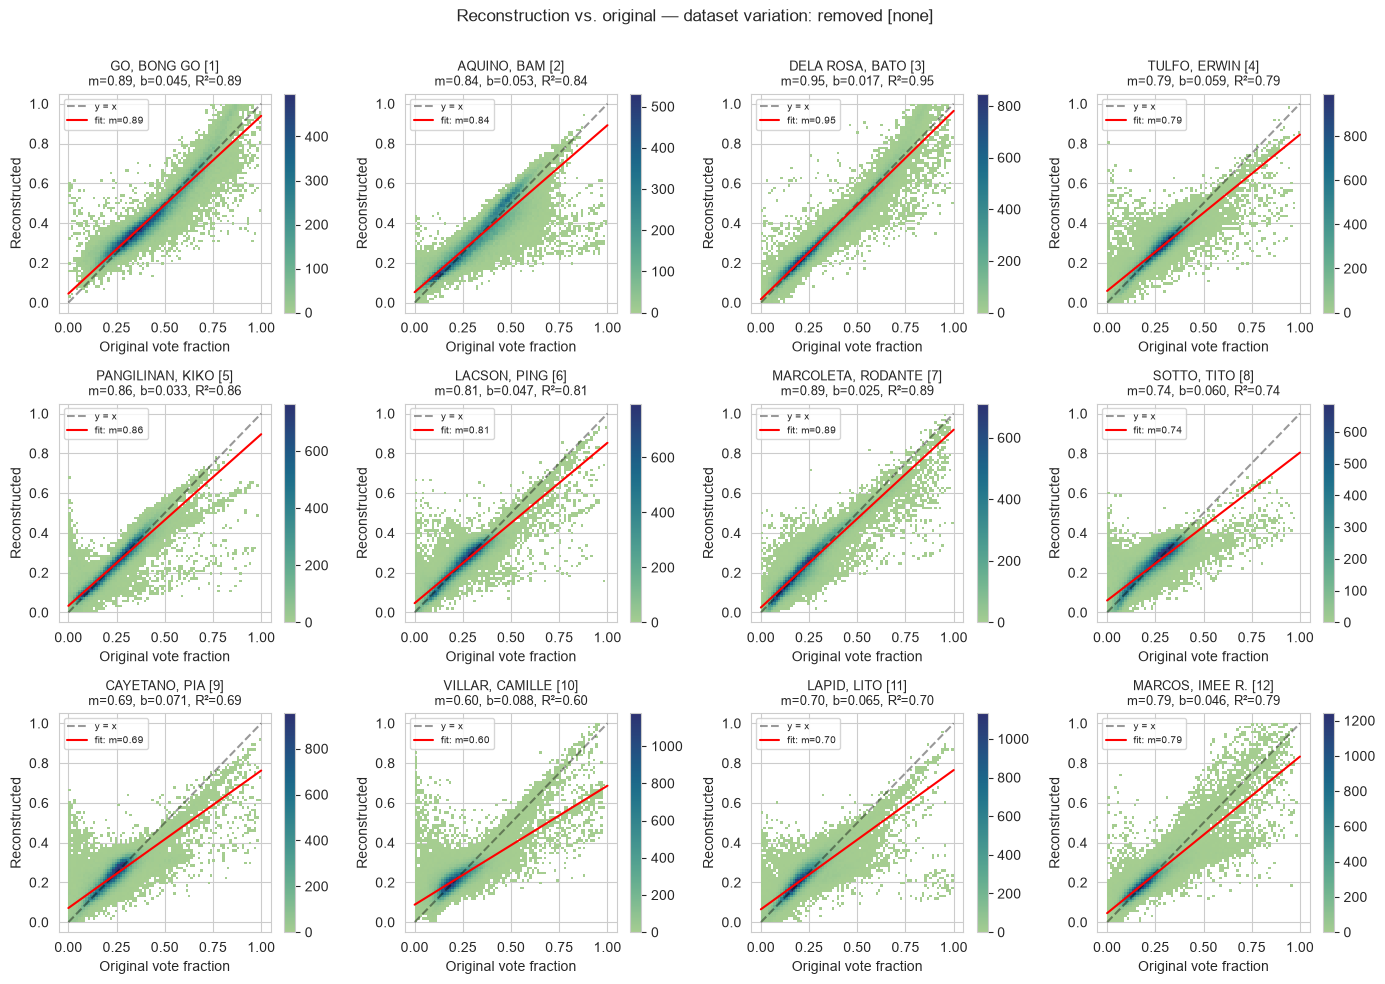

In [7]:
plot_reconstruction_heatmaps(base, Y, labels, n_show=TOP_N)

#### Heatmaps for each dataset variation

One grid per removed candidate. The removed candidate is absent from its own
grid; the remaining top candidates are shown so their fits can be compared
against the baseline above.

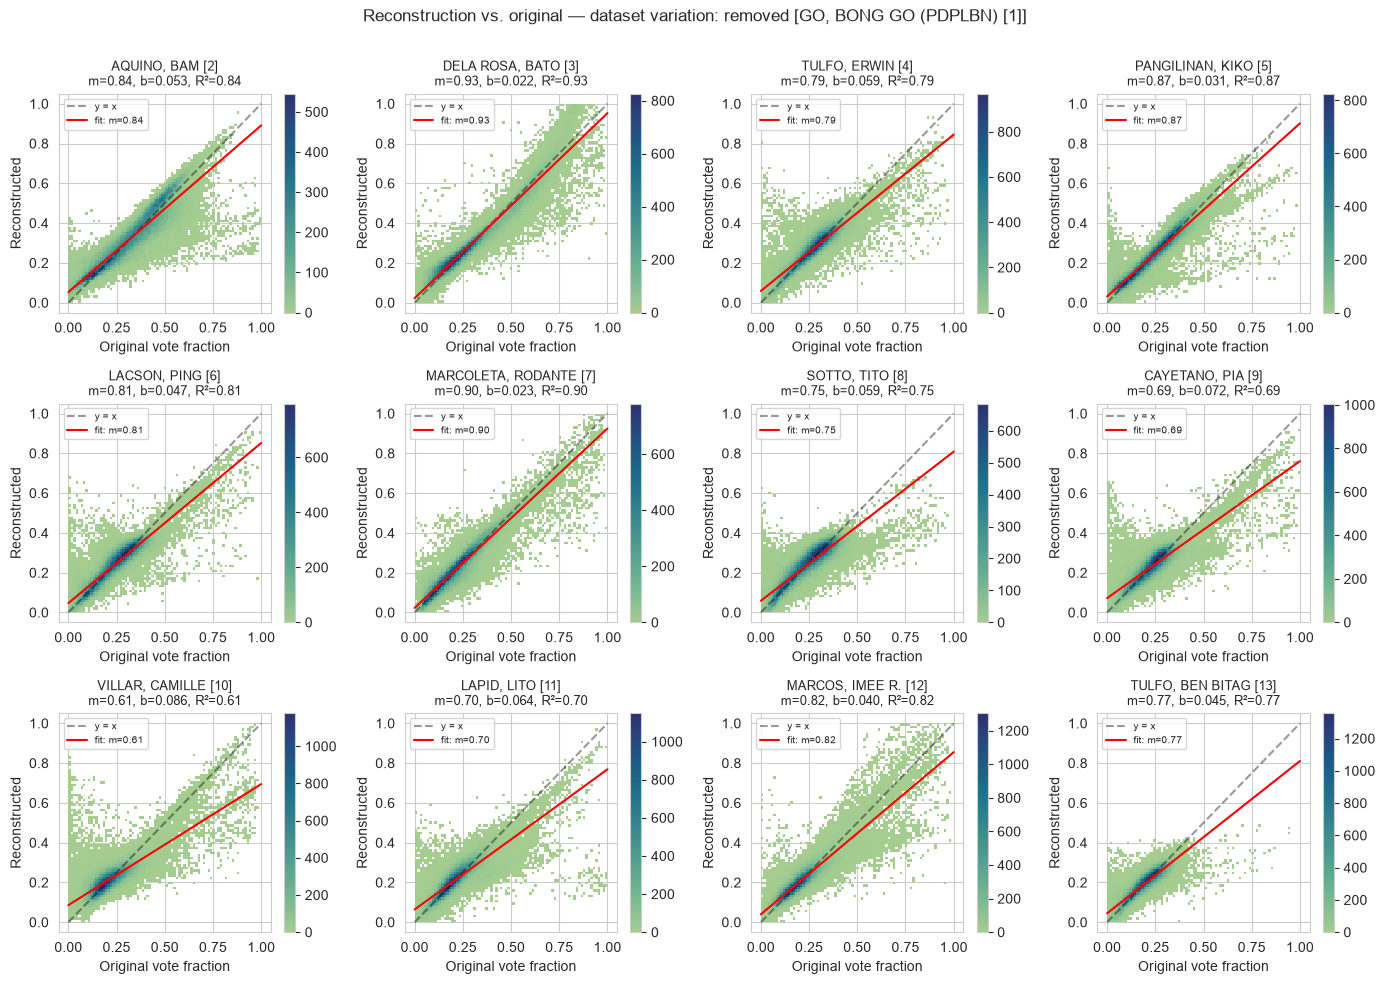

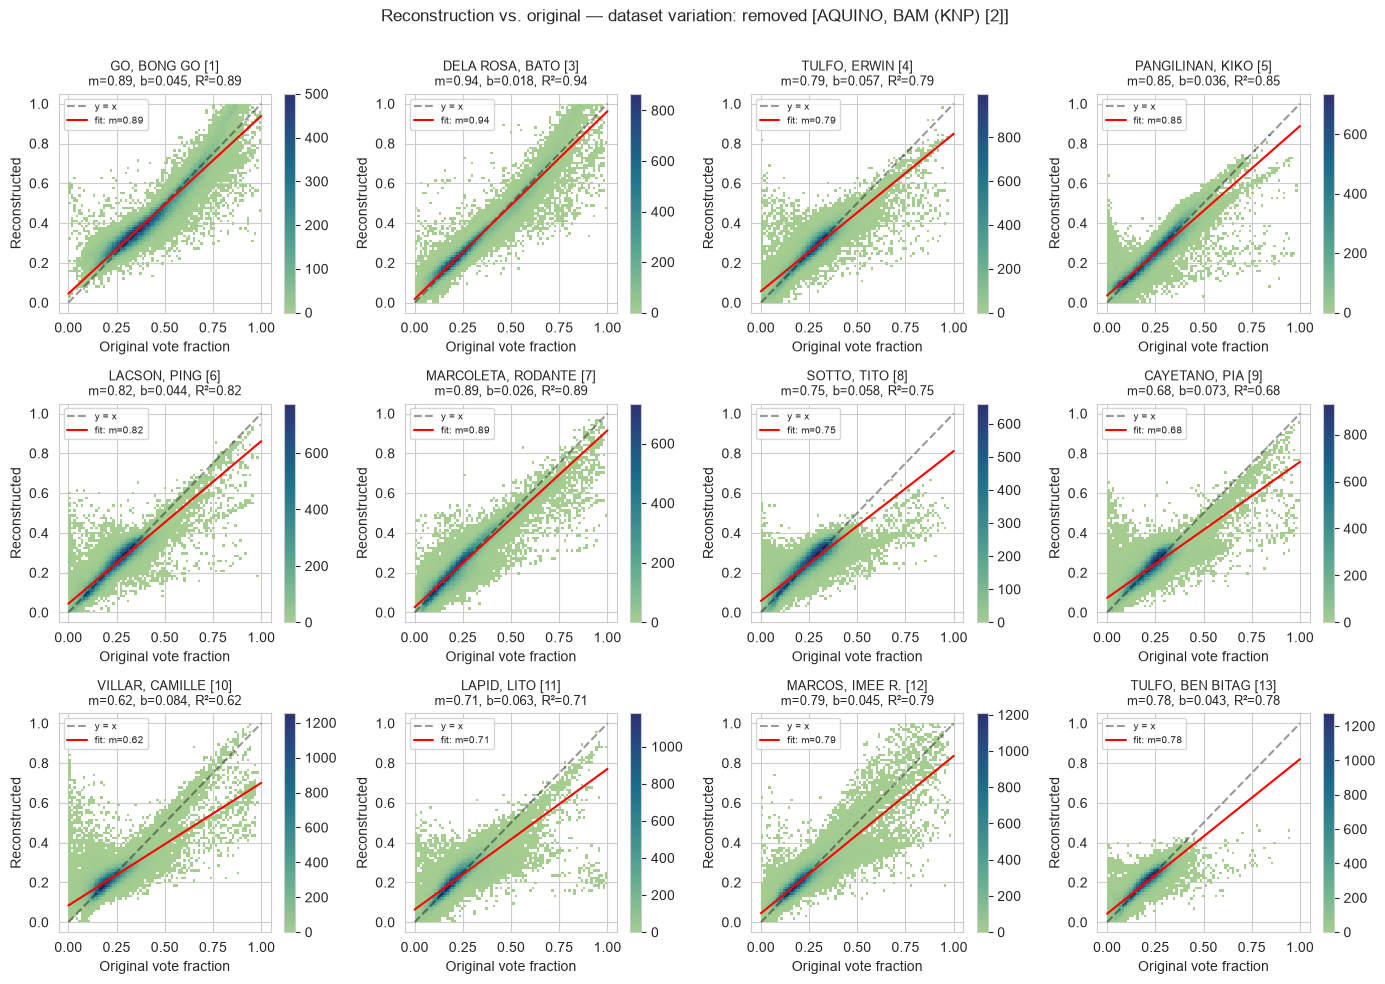

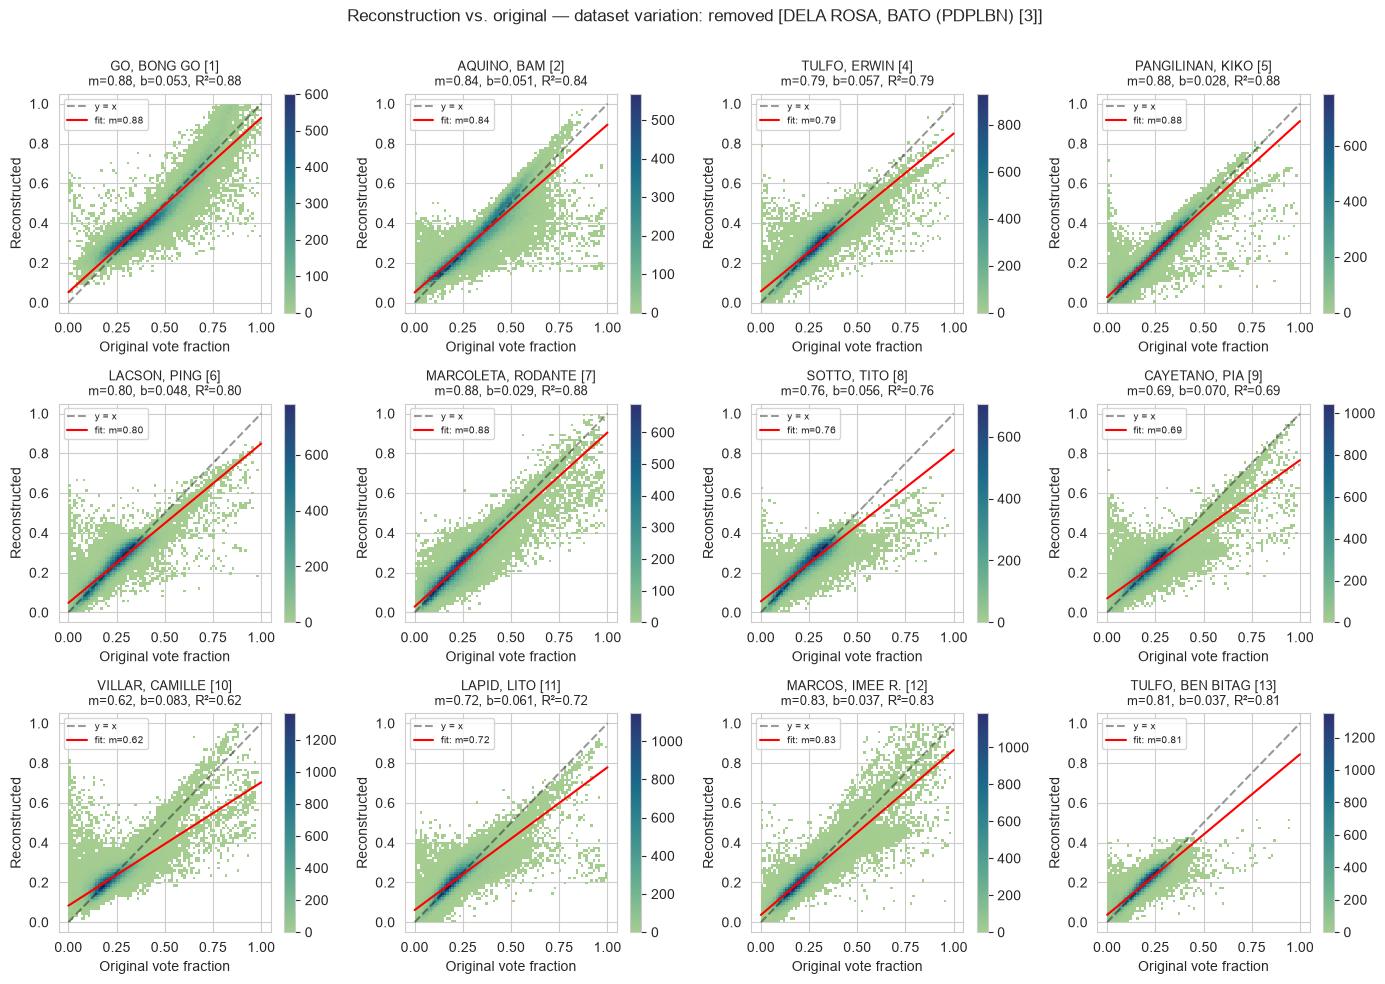

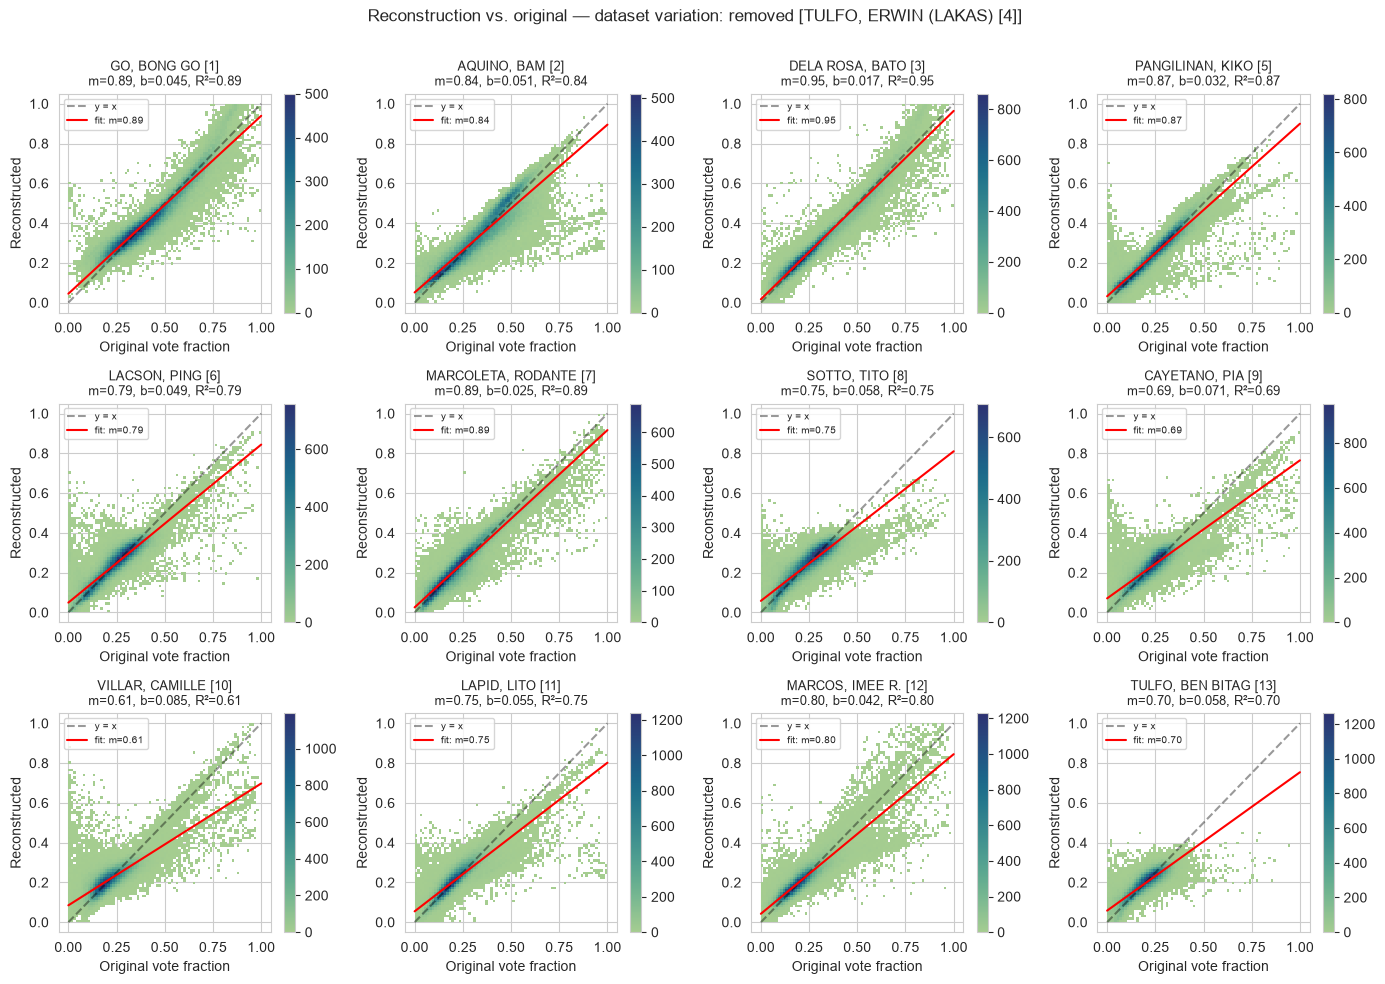

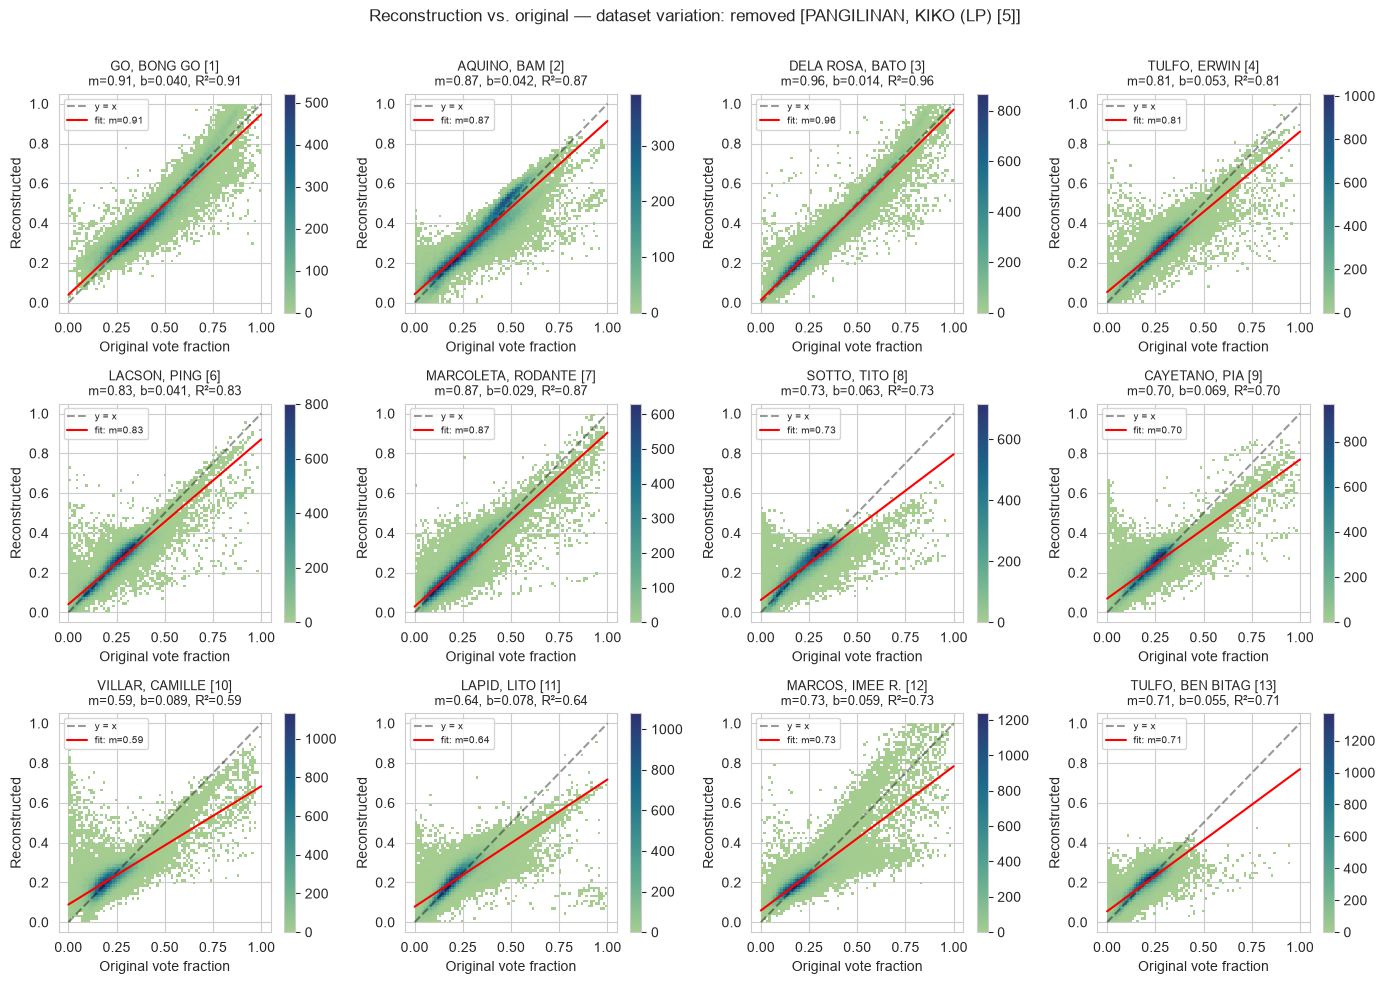

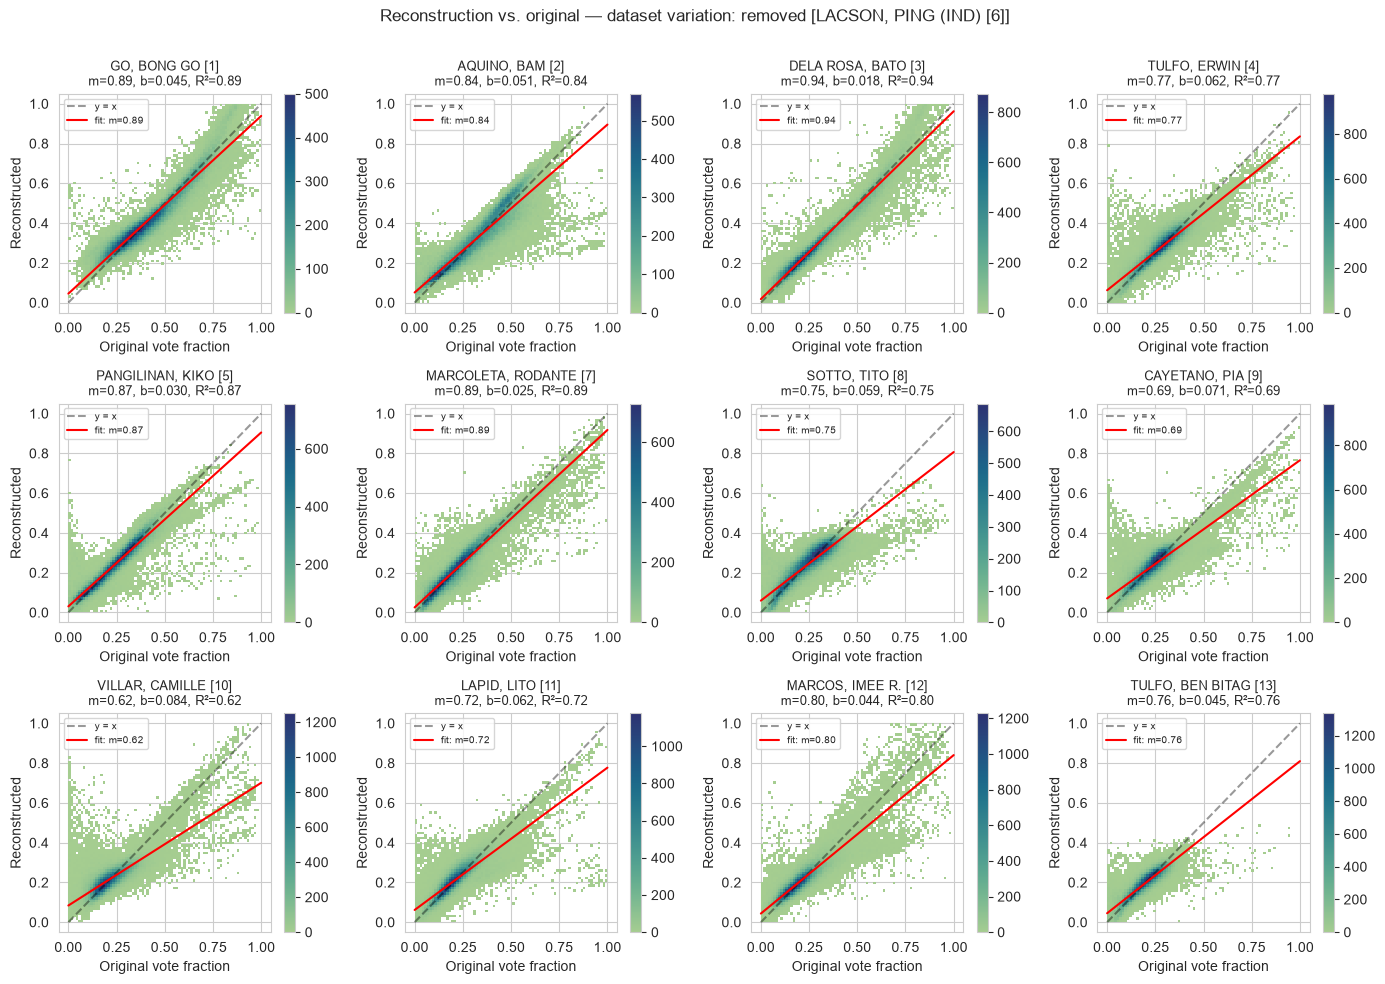

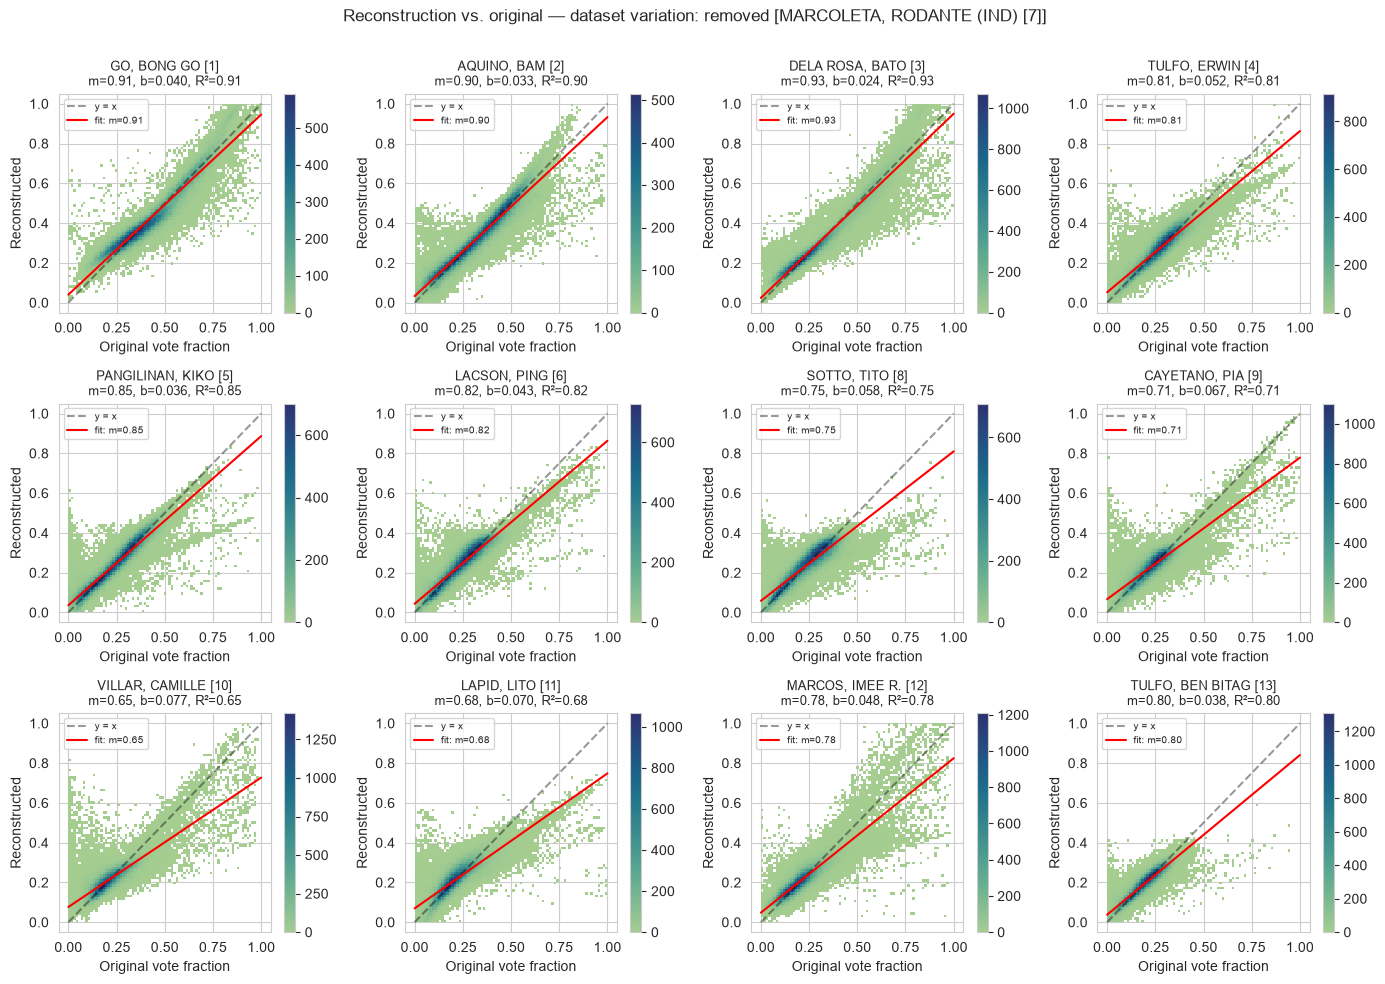

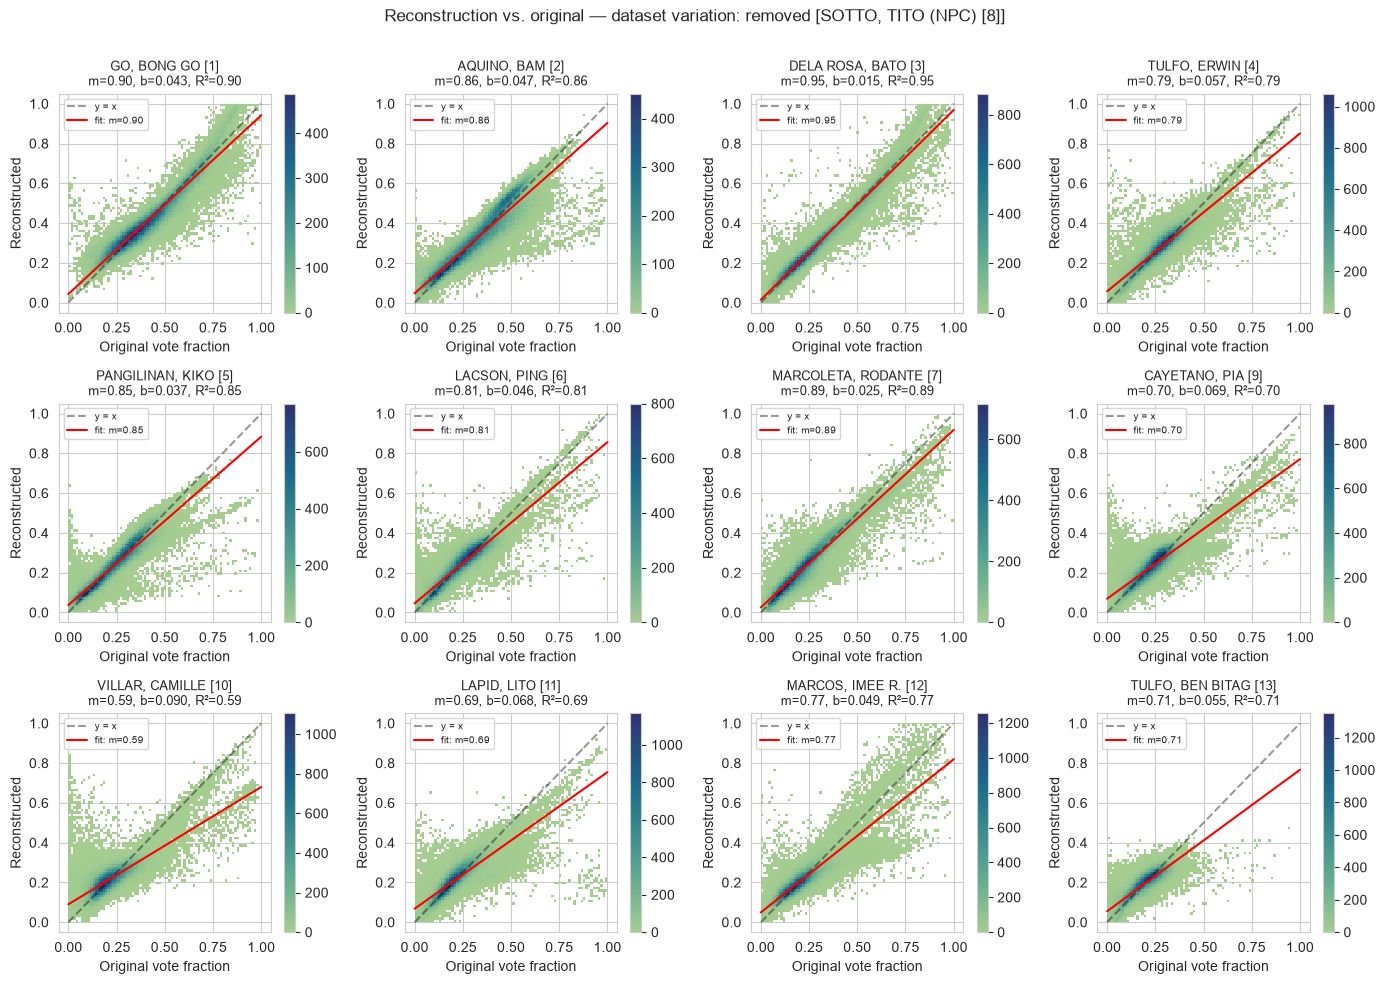

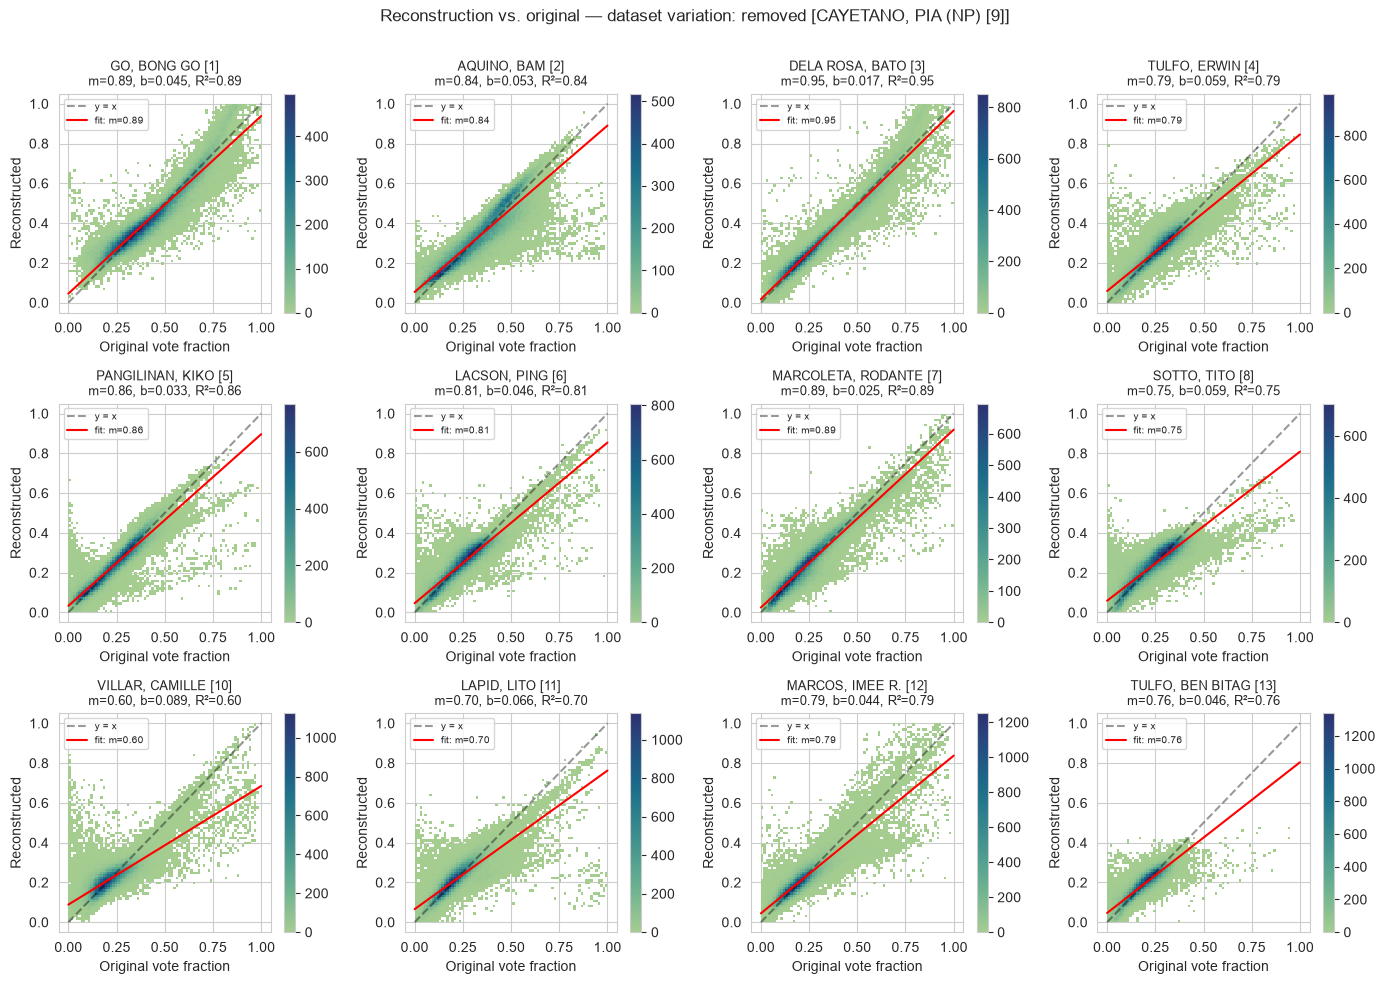

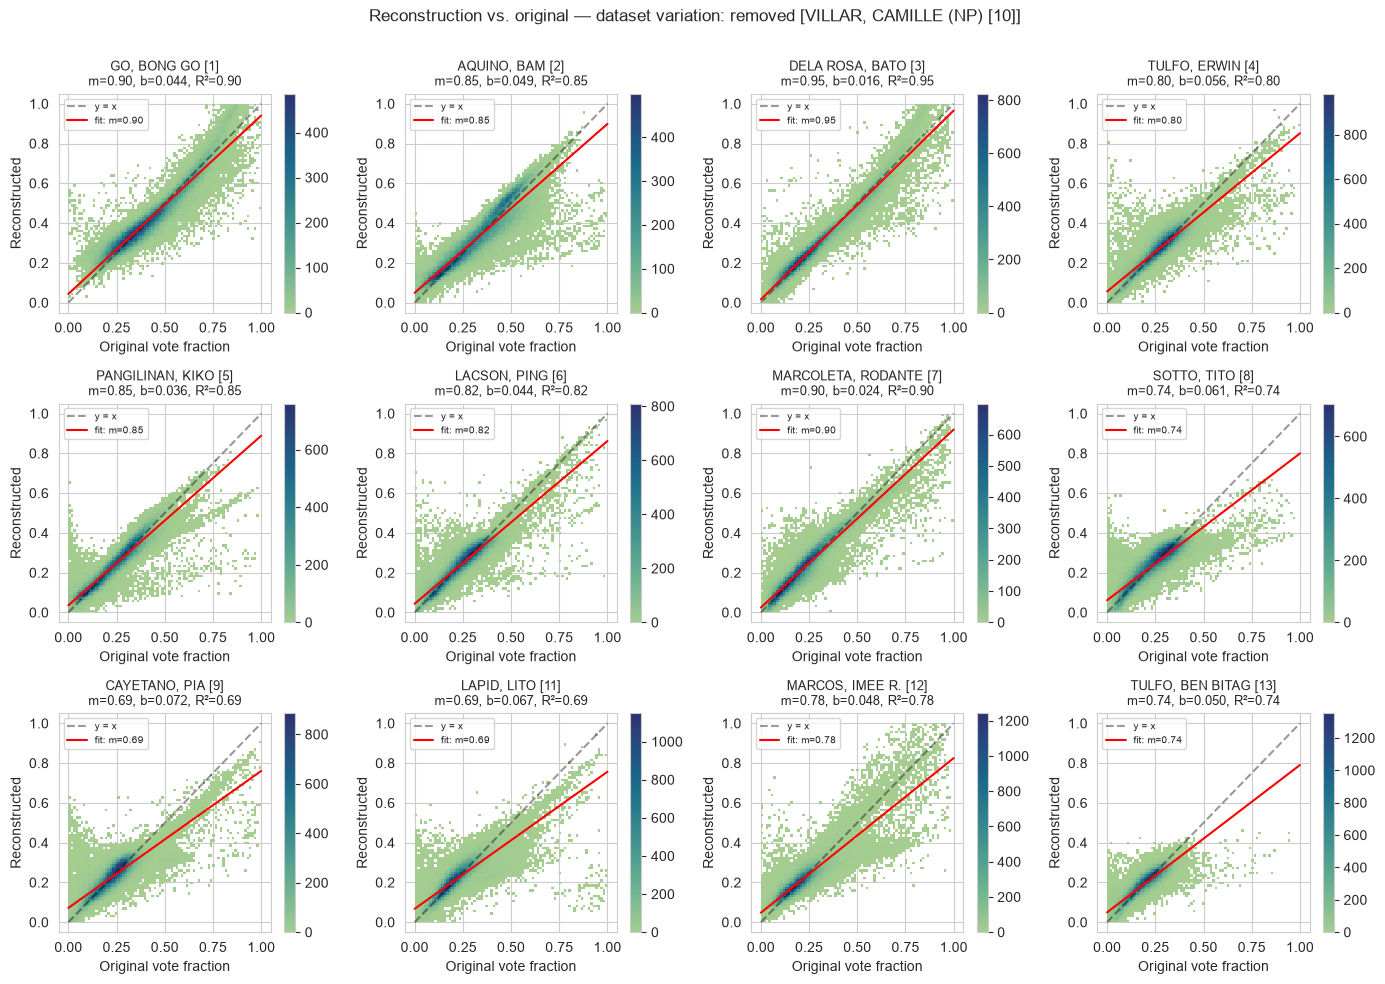

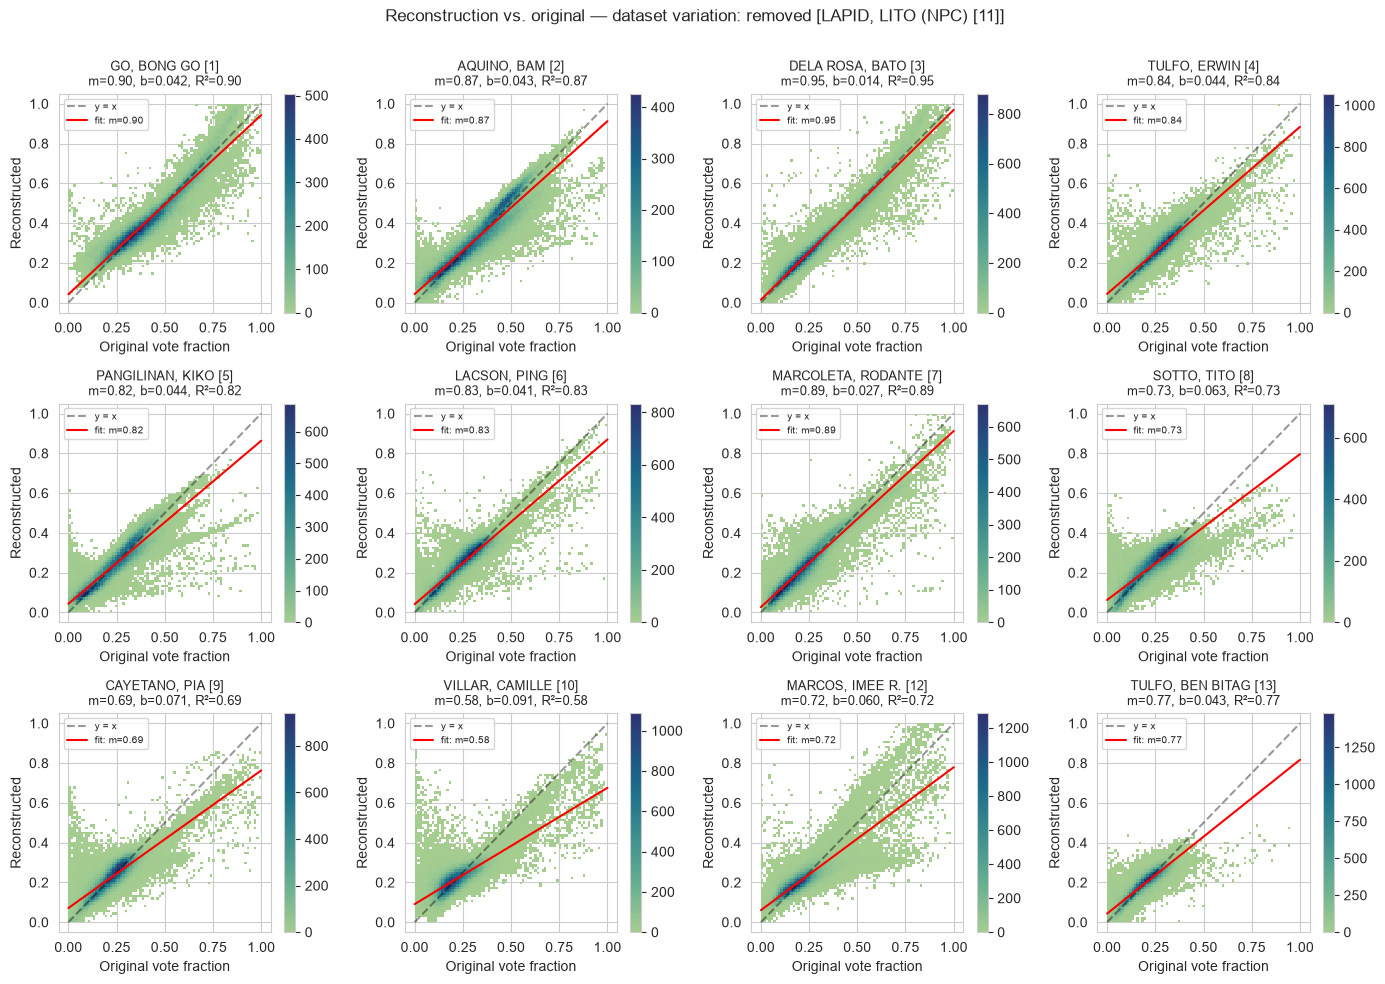

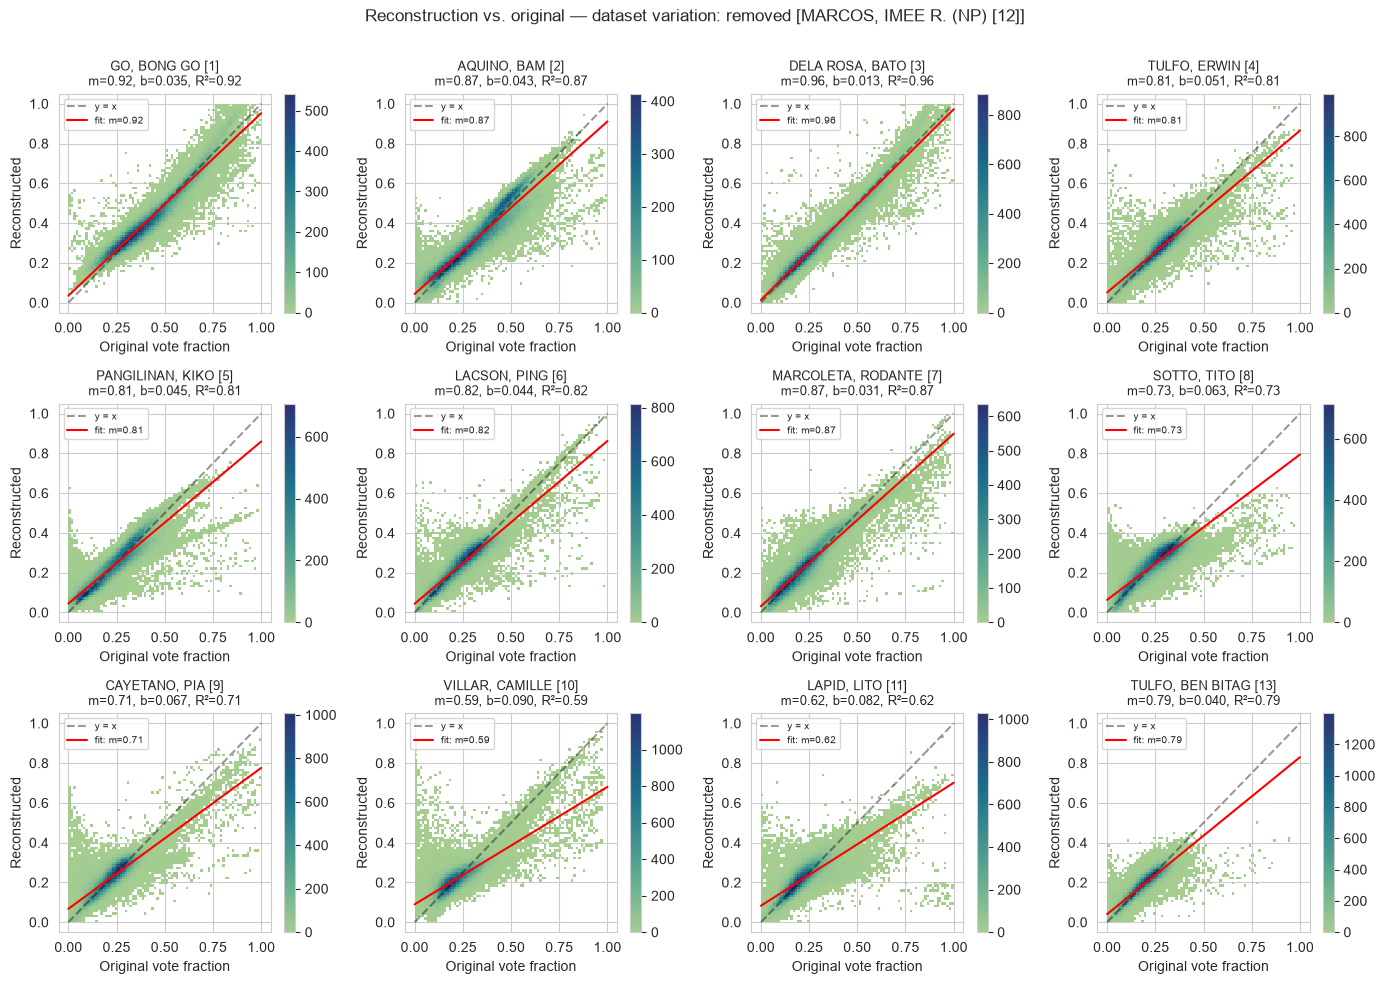

In [8]:
for res in results:
    plot_reconstruction_heatmaps(res, Y, labels, n_show=TOP_N)

## Summary — linear fit across dataset variations

The matrices below collect the linear-fit statistics of the **top `TOP_N`
candidates** (rows) across every dataset variation (columns). Column *None* is
the baseline; column *rm: X* is the variation with candidate *X* removed. The
diagonal-style blank cell in each removal column is the candidate that was
removed (no reconstruction exists for it there).

- **Slope** — sensitivity of faithfulness: how far each candidate's
  reconstruction slope moves when some *other* top candidate is dropped.
- **R²** — how much of each candidate's precinct-level variance the model still
  explains under each variation.

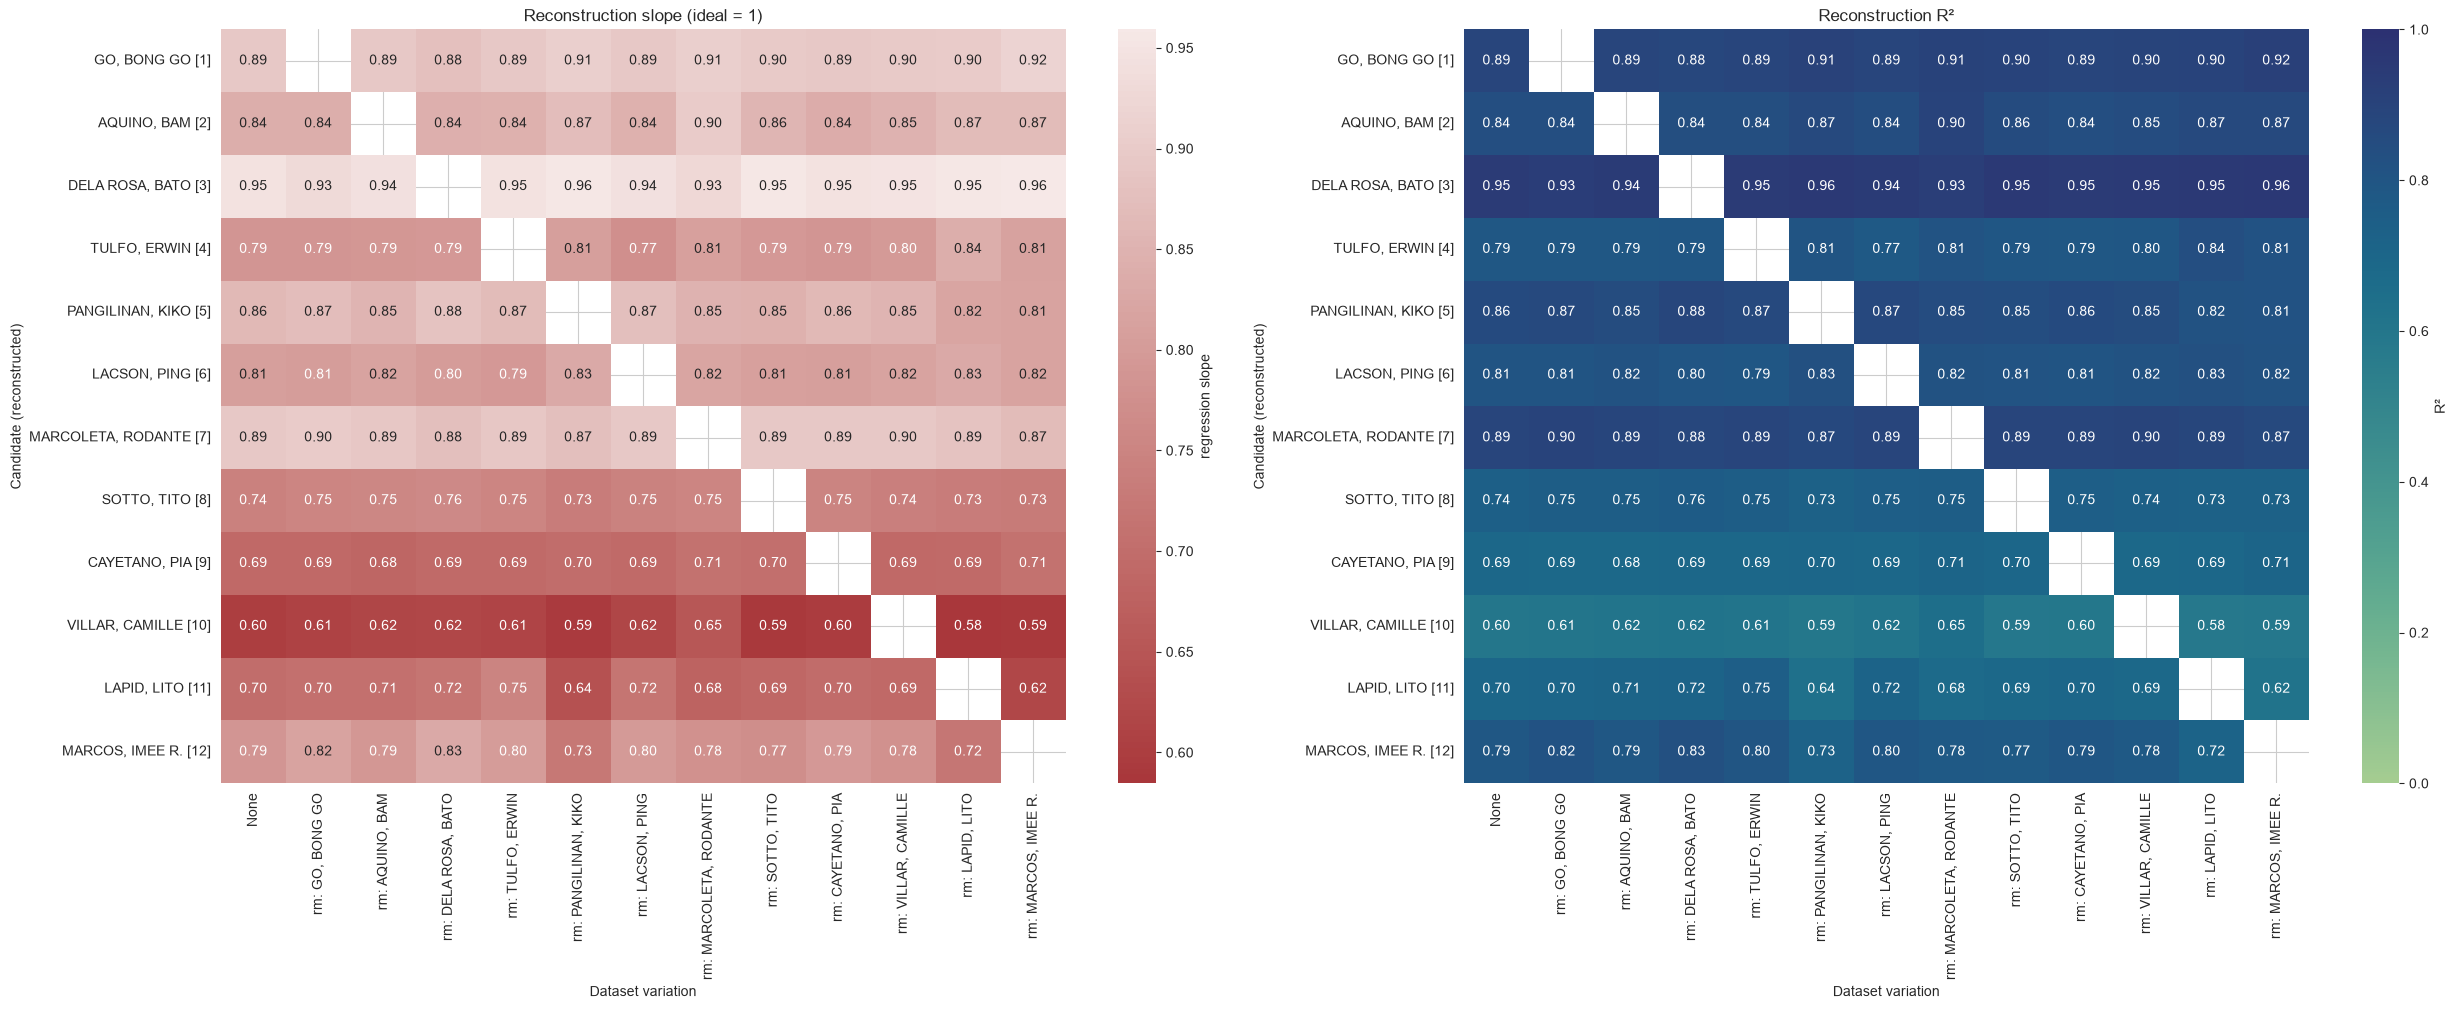

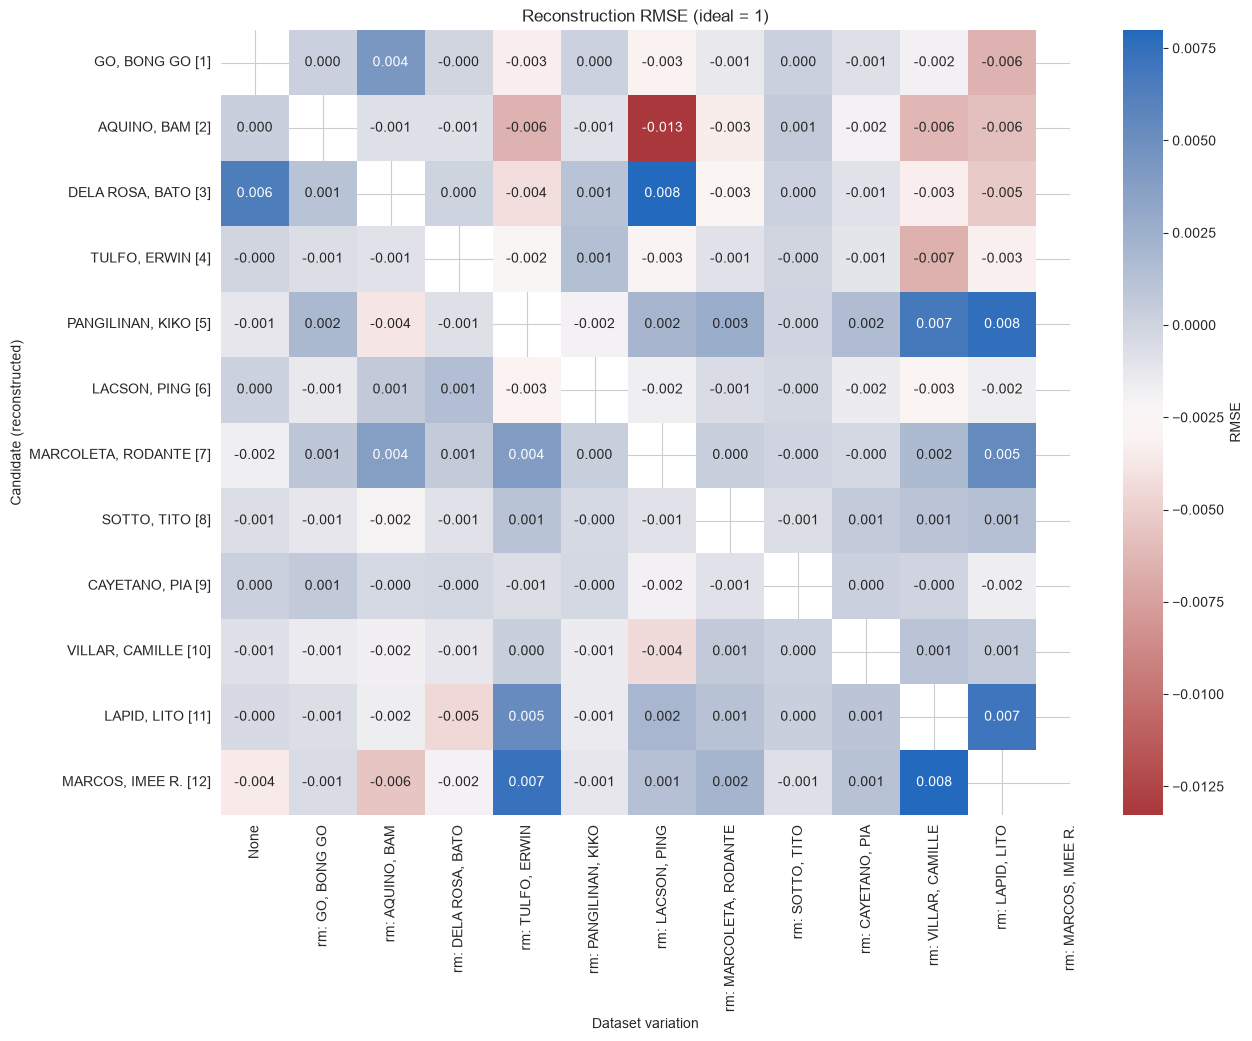

In [ ]:
top = list(range(TOP_N))
row_labels = [short_label(labels[i]) for i in top]
col_labels = ['None'] + [f'rm: {short_label(labels[k]).rsplit(" [", 1)[0]}' for k in top]

slope_mat = np.full((TOP_N, len(col_labels)), np.nan)
r2_mat = np.full((TOP_N, len(col_labels)), np.nan)
rmse_mat = np.full((TOP_N, len(col_labels)), np.nan)

# Baseline column.
for r, i in enumerate(top):
    slope_mat[r, 0] = base['fit'][i]['slope']
    r2_mat[r, 0] = base['fit'][i]['r2']
    rmse_mat[r, 0] = base['fit'][i]['rmse']

# One column per removal variation.
for c, res in enumerate(results, start=1):
    for r, i in enumerate(top):
        if i in res['fit']:
            slope_mat[r, c] = res['fit'][i]['slope']
            r2_mat[r, c] = res['fit'][i]['r2']
            rmse_mat[r, c] = res['fit'][i]['rmse']

fig, axs = plt.subplots(1, 2, figsize=(2 + 0.9 * len(col_labels) * 2, 0.6 * TOP_N + 3))
sns.heatmap(slope_mat, ax=axs[0], cmap='vlag_r', center=1.0,
            xticklabels=col_labels, yticklabels=row_labels,
            annot=True, fmt='.2f', #annot_kws={'fontsize': 7},
            cbar_kws={'label': 'regression slope'})
axs[0].set_title('Reconstruction slope (ideal = 1)')
sns.heatmap(r2_mat, ax=axs[1], cmap='crest', vmin=0, vmax=1,
            xticklabels=col_labels, yticklabels=row_labels,
            annot=True, fmt='.2f', #annot_kws={'fontsize': 7},
            cbar_kws={'label': 'R\u00b2'})
axs[1].set_title('Reconstruction R\u00b2')

for ax in axs:
    ax.set_xlabel('Dataset variation')
    ax.set_ylabel('Candidate (reconstructed)')
    ax.tick_params(axis='x', rotation=90)

fig.tight_layout()



fig, ax = plt.subplots(1, 1, figsize=(2 + 0.9 * len(col_labels), 0.6 * TOP_N + 3))
sns.heatmap(rmse_mat[:, 1:] - np.array([rmse_mat[:, 0]] * 12).T, ax=ax, cmap='vlag_r',
            xticklabels=col_labels, yticklabels=row_labels,
            annot=True, fmt='.3f', #annot_kws={'fontsize': 7},
            cbar_kws={'label': 'RMSE'})
ax.set_title('Reconstruction RMSE difference from baseline')
ax.set_xlabel('Dataset variation')
ax.set_ylabel('Candidate (reconstructed)')
ax.tick_params(axis='x', rotation=90)

### Overall effect of each removal

A compact view of how much removing each candidate perturbs the model as a
whole: the change in global RMSE relative to the baseline, and the mean
absolute change in the other top candidates' reconstruction slopes.

In [10]:
base_slopes = {i: base['fit'][i]['slope'] for i in range(L)}
removed_names = [short_label(r['removed_label']).rsplit(' [', 1)[0] for r in results]

dslopes = np.array([
    [(r['fit'][i]['slope'] - base_slopes[i]) for i in r['keep']]
    for r in results
])



Text(0.5, 1.02, 'Distribution of candidate slope shifts')

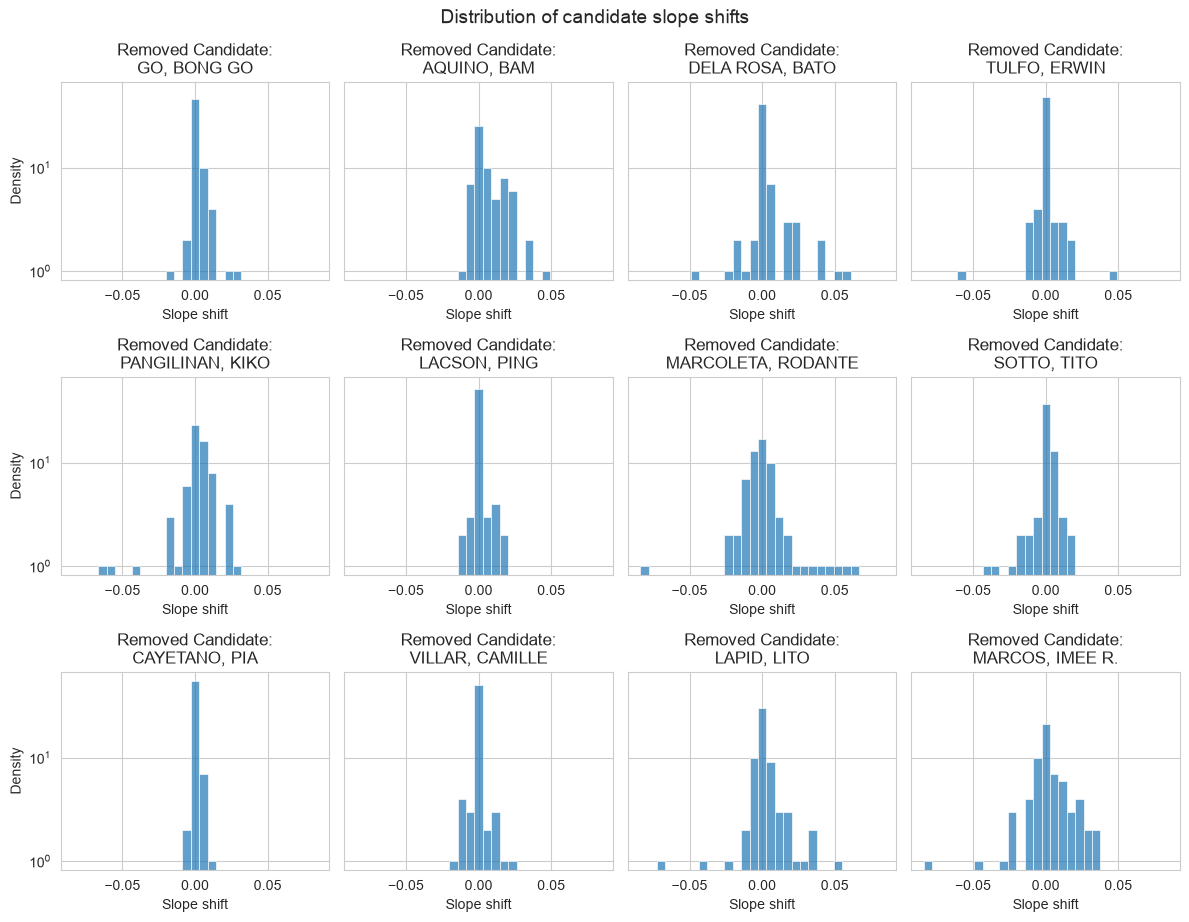

In [11]:
fig, axs = plt.subplots(3, 4, figsize=(4 * 3, 3 * 3), sharey=True)
max_abs_dslope = np.max(np.abs(dslopes.flatten()))
bins = np.linspace(-max_abs_dslope, max_abs_dslope, 30)

for i in range(dslopes.shape[0]):
    ax_row = i // 4
    ax_col = i % 4
    ax = axs[ax_row, ax_col]
    sns.histplot(ax=ax, data=dslopes[i], bins=bins, color='C0', alpha=0.7, stat='count')
    ax.set_title(f'Removed Candidate:\n{removed_names[i]}')
    ax.set_xlabel('Slope shift')
    ax.set_ylabel('Density')
    ax.set_yscale('log')
    # ax.set_xlim(min(dslopes.flatten()), max(dslopes.flatten()))

plt.tight_layout()
plt.suptitle('Distribution of candidate slope shifts', fontsize=14, y=1.02)

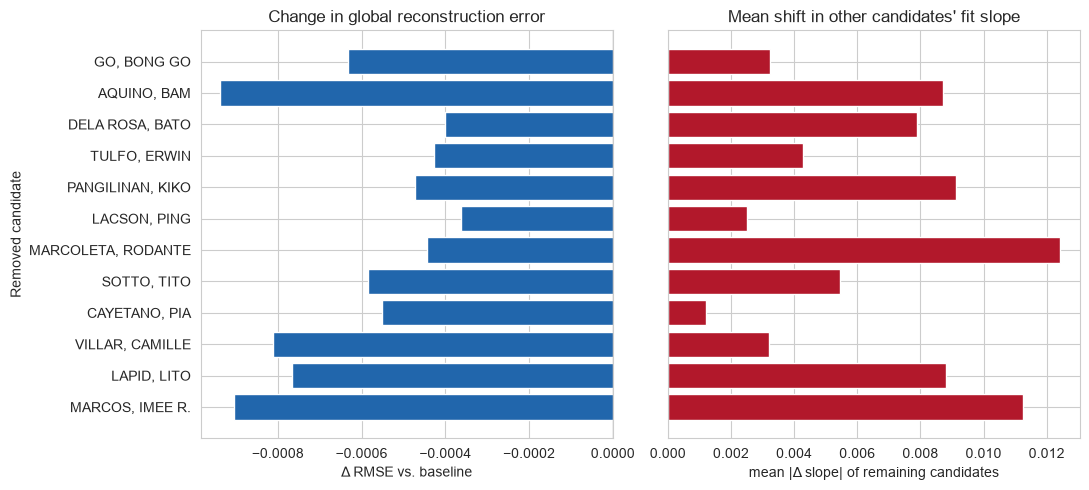

In [12]:
d_rmse = [r['rmse'] - base['rmse'] for r in results]
mean_abs_dslope = [
    float(np.mean([abs(r['fit'][i]['slope'] - base_slopes[i]) for i in r['keep']]))
    for r in results
]

fig, axs = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
axs[0].barh(range(len(results)), d_rmse, color='#2166ac')
axs[0].axvline(0, color='black', lw=0.8)
axs[0].set_xlabel('Δ RMSE vs. baseline')
axs[0].set_title('Change in global reconstruction error')

axs[1].barh(range(len(results)), mean_abs_dslope, color='#b2182b')
axs[1].set_xlabel('mean |Δ slope| of remaining candidates')
axs[1].set_title('Mean shift in other candidates\' fit slope')

for ax in axs:
    ax.set_yticks(range(len(results)))
    ax.set_yticklabels(removed_names)
axs[0].set_ylabel('Removed candidate')
axs[0].invert_yaxis()  # top candidate at the top

fig.tight_layout()
plt.show()